In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
)

In [2]:
Datasource = 'C:/Users/sushe/Documents/Kantar/Fraud Detection/data/datasets.csv'
OUT_DIR = "C:/Users/sushe/Documents/Kantar/Fraud Detection/outputs"
os.makedirs(OUT_DIR, exist_ok=True)
RANDOM_STATE = 42

In [3]:
df = pd.read_csv(Datasource, parse_dates=["registration_timestamp"])

NUMERIC_FEATURES = [
    "age", "reg_duration_s", "reg_hour", "reg_dayofweek",
    "reg_is_night", "email_is_freemail",
]
CATEGORICAL_FEATURES = [
    "email_domain", "gender", "job_title", "education_level",
    "os", "device_type", "is_smoker", "is_drinker",
]

ts = df["registration_timestamp"]
df["reg_hour"] = ts.dt.hour
df["reg_dayofweek"] = ts.dt.dayofweek
df["reg_is_night"] = ts.dt.hour.isin([0, 1, 2, 3, 4, 5]).astype(int)

df["email_is_freemail"] = df["email_domain"].isin(["gmail.com", "yahoo.com", "hotmail.com", "outlook.com"]).astype(int)
df["reg_duration_s"] = df["registration_duration_ms"] / 1000.0

for col in ["is_smoker", "is_drinker"]:
    df[col] = df[col].astype(str)

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df["is_fraud"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean():.2%}  |  Test fraud rate: {y_test.mean():.2%}")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

numeric = Pipeline([("impute", SimpleImputer(strategy="median")),("scale", StandardScaler()),])
categorical = Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="MISSING")),("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),])
preproc = ColumnTransformer([("num", numeric, NUMERIC_FEATURES),("cat", categorical, CATEGORICAL_FEATURES),])

Train: (37500, 14)  Test: (12500, 14)
Train fraud rate: 5.00%  |  Test fraud rate: 5.00%


In [4]:
models = {
        "LogisticRegression": LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, max_depth=None, min_samples_leaf=2,
            class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
        ),
        "XGBoost": XGBClassifier(
            n_estimators=400, max_depth=5, learning_rate=0.08,
            subsample=0.9, colsample_bytree=0.9,
            scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
            random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
        ),
    }

def evaluate(name, pipe, X_test, y_test):
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    roc = roc_auc_score(y_test, proba)
    pr = average_precision_score(y_test, proba)
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"ROC-AUC : {roc:.4f}")
    print(f"PR-AUC  : {pr:.4f}")
    print("\nClassification report (threshold = 0.5):")
    print(classification_report(y_test, pred, digits=3))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))
    return {"model": name, "roc_auc": roc, "pr_auc": pr, "proba": proba}


LogisticRegression
ROC-AUC : 0.9680
PR-AUC  : 0.7725

Classification report (threshold = 0.5):
              precision    recall  f1-score   support

           0      0.994     0.921     0.956     11875
           1      0.371     0.888     0.524       625

    accuracy                          0.919     12500
   macro avg      0.683     0.904     0.740     12500
weighted avg      0.963     0.919     0.934     12500

Confusion matrix:
[[10936   939]
 [   70   555]]

RandomForest
ROC-AUC : 0.9597
PR-AUC  : 0.7623

Classification report (threshold = 0.5):
              precision    recall  f1-score   support

           0      0.982     0.987     0.985     11875
           1      0.725     0.666     0.694       625

    accuracy                          0.971     12500
   macro avg      0.854     0.826     0.839     12500
weighted avg      0.970     0.971     0.970     12500

Confusion matrix:
[[11717   158]
 [  209   416]]

XGBoost
ROC-AUC : 0.9613
PR-AUC  : 0.7537

Classification rep

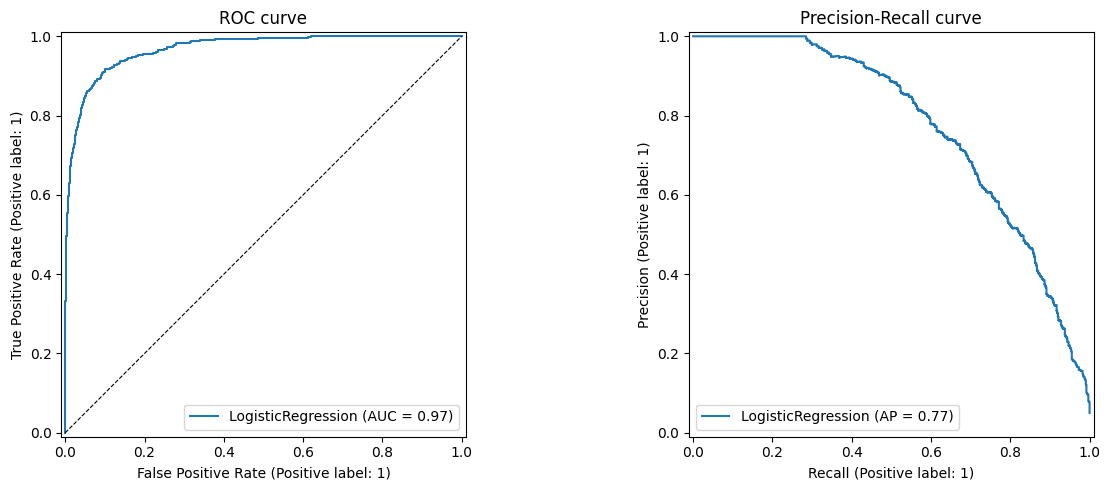

In [5]:
results = []
fitted = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preproc), ("clf", model)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    roc = roc_auc_score(y_test, proba)
    pr = average_precision_score(y_test, proba)
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"ROC-AUC : {roc:.4f}")
    print(f"PR-AUC  : {pr:.4f}")
    print("\nClassification report (threshold = 0.5):")
    print(classification_report(y_test, pred, digits=3))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))
    results.append({"model": name, "roc_auc": roc, "pr_auc": pr, "proba": proba})
    fitted[name] = pipe

best = max(results, key=lambda r: r["pr_auc"])
print(f"\n>>> BEST MODEL (by PR-AUC): {best['model']}  "f"(PR-AUC={best['pr_auc']:.4f}, ROC-AUC={best['roc_auc']:.4f})")
best_pipe = fitted[best["model"]]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_predictions(y_test, best["proba"], ax=ax[0], name=best["model"])
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8); ax[0].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, best["proba"], ax=ax[1], name=best["model"])
ax[1].set_title("Precision-Recall curve")
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/task2_curves.png", dpi=120)

clf = best_pipe.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
    imp = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False).head(20)
    fig2, ax2 = plt.subplots(figsize=(9, 7))
    imp[::-1].plot.barh(ax=ax2)
    ax2.set_title(f"Top 20 feature importances — {best['model']}")
    fig2.tight_layout(); fig2.savefig(f"{OUT_DIR}/task2_feature_importance.png", dpi=120)
    print("\nTop 10 features:")
    print(imp.head(10).round(4).to_string())

summary = pd.DataFrame([{k: v for k, v in r.items() if k != "proba"} for r in results])
summary.to_csv(f"{OUT_DIR}/task2_model_comparison.csv", index=False)
print(f"\nArtifacts saved to {OUT_DIR}/")